#  Ziel:
Mit wenig Rechenleistung/Aufwand vielversprechende Reinforcement Learning (folgend RL) Ansätze identifizieren. Diese werden in Isaac Sim umgesetzt. Damit wird rechenintensives Trial an Error in Isaac Sim umgangen.


## Ansätze aus Brainstorming:

### Ideen für die Verwendung von Bildinformationen:

-Gerichtetes Birdseye - Dauerhafte Autofeste-Vogelperspektive (zuschnitt)

-Gesamtes Bild - Weltfeste Kamera, gesamte Strecke im Bild

-Vorverarbeitung des Bilds, um Geschwindigkeit, Position(Pixelkoordinaten) und Ausrichtung zu extrahieren

### Ideen für die KI-Inputs:

-1 Bild

-2 oder 3 Bilder

-Die letzten Outputs der KI (Geschwindigkeitsbefehl entspricht nährungsweise der Geschwindigkeit des Autos)

-Parameter des Fahrzeugs, von Computervision (folgend CV) extrahiert


## Umgebung erzeugen

Rennstrecke als Bild initialisieren, anschließend das Auto initialisieren

In [ ]:
import matplotlib.pyplot as plt
import cv2
img = cv2.imread("data/strecke.png")
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Strecke/Umgebung auf welcher gefahren wird")
plt.show()

img_car = cv2.imread("data/carrera_car.png")
plt.figure(figsize=(5, 3))
plt.imshow(cv2.cvtColor(img_car, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Carrera Auto")
plt.show()

## Das Spiel mit PyGame auf Basis von carrera_2d_env.py erstellen

In [ ]:
import pygame
import numpy as np
from src.envs.carrera_2d_env import Carrera2DEnv

# 1. Environment initialisieren
# (Pfade anpassen, falls nötig)
env = Carrera2DEnv(track_image_path="data/strecke.png", 
                   car_image_path="data/carrera_car.png")

# Startzustand abrufen
obs, info = env.reset()

# 2. Pygame Setup für die Notebook-Integration
pygame.init()
clock = pygame.time.Clock()
running = True

print("🎮 WASD Steuerung aktiv. Klicke auf das Pygame-Fenster!")
print("Drücke ESC oder schließe das Fenster, um zu beenden.")

# 3. Der Main Loop
while running:
    # A) Fenster-Events abfangen (sonst stürzt das Fenster ab)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False

    # B) WASD Tasten abfragen
    keys = pygame.key.get_pressed()
    
    # Gas (W = 1.0, Leerlauf = 0.0)
    gas = 0.5 if keys[pygame.K_w] else 0.0
    
    # Bremse (S = 1.0, Leerlauf = 0.0)
    brake = 0.1 if keys[pygame.K_s] else 0.0
    
    # Lenkung (A = links (-1.0), D = rechts (1.0))
    steer = 0.0
    if keys[pygame.K_a]:
        steer = -0.4
    elif keys[pygame.K_d]:
        steer = 0.4

    # Action-Vektor für das Environment erstellen
    action = np.array([gas, brake, steer], dtype=np.float32)

    # C) Physik-Schritt ausführen
    # Hier feuert deine Einspurmodell-Logik
    obs, reward, terminated, truncated, info = env.step(action)

    # D) Bild zeichnen
    env.render()

    # E) FPS limitieren (entspricht Delta t von ~0.033s)
    clock.tick(30)

# 4. Aufräumen, wenn die Schleife beendet wird
env.close()
pygame.quit()
print("🛑 Simulation beendet.")

Werte ermitteln für die open-cv Farbmaskierung im hsv-Farbraum
Das Reglerfenster kann mit der Q Taste beendet werden, wodurch die aktuellen Reglerwerte unter der Zelle als Output angezeigt werden.

In [ ]:
import cv2
import numpy as np

def nothing(x):
    pass

# Bild laden
image_path = 'data/strecke.png'
img = cv2.imread(image_path)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Fenster erstellen
cv2.namedWindow('Tuning')

# Trackbars für Lower und Upper HSV erstellen
# Standardwerte für Blau sind ca. H:100-130
cv2.createTrackbar('Low H', 'Tuning', 100, 179, nothing)
cv2.createTrackbar('High H', 'Tuning', 130, 179, nothing)
cv2.createTrackbar('Low S', 'Tuning', 50, 255, nothing)
cv2.createTrackbar('High S', 'Tuning', 255, 255, nothing)
cv2.createTrackbar('Low V', 'Tuning', 50, 255, nothing)
cv2.createTrackbar('High V', 'Tuning', 255, 255, nothing)

print("Regle die Werte, bis nur noch die blaue Begrenzung weiß ist.")
print("Drücke 'q' zum Beenden und Anzeigen der finalen Werte.")

while True:
    # Aktuelle Positionen der Trackbars abfragen
    lh = cv2.getTrackbarPos('Low H', 'Tuning')
    hh = cv2.getTrackbarPos('High H', 'Tuning')
    ls = cv2.getTrackbarPos('Low S', 'Tuning')
    hs = cv2.getTrackbarPos('High S', 'Tuning')
    lv = cv2.getTrackbarPos('Low V', 'Tuning')
    hv = cv2.getTrackbarPos('High V', 'Tuning')

    # Maske erstellen
    lower = np.array([lh, ls, lv])
    upper = np.array([hh, hs, hv])
    mask = cv2.inRange(hsv, lower, upper)

    # Ergebnis anzeigen
    cv2.imshow('Tuning', mask)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        print(f"\nFinale Werte für deine tracklimits_cv.py:")
        print(f"Lower: [{lh}, {ls}, {lv}]")
        print(f"Upper: [{hh}, {hs}, {hv}]")
        break

cv2.destroyAllWindows()

## Grenzenermittlung mittels open-cv

Um später einen Reward/Bestrafung berechnen zu können braucht es eine Mittelinie, um überall die Fahrrichtung zu kennen, Eine Start und Ziellinie und natürlich die Streckengrenzen, welche nicht überfahren werden dürfen. Diese werden mittels der Farben und Bildverarbeitung extrahiert und hinterlegt. In der folgenden Zelle wird das Skript tracklimits_cv.py genutzt um die Begrenzungen zu berechnen, Masken von Rot und Blau zu speichern und auf der Strecke die Begrenzungen anzuzeigen.

Die Ziellinie müssen wir nicht mit Computervision erfassen, es ist deutlich leichter diese durch ihre Ecken zu definieren (Ecken oben links und unten rechts) spannen ein passendes Rechteck auf. In Gimp abgemessen: Ecke oben links: (462|55) und unten rechts: (468|114).

In [ ]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.utils.tracklimits_cv import TrackProcessor, TrackAnalyzer

# 1. Pfad definieren und Bild laden (für den Hintergrund des Plots)
image_path = 'data/strecke.png'
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Matplotlib braucht RGB

# 2. Masken extrahieren
processor = TrackProcessor(image_path)
blue_mask, red_mask = processor.extract_track_logic()

# 3. Den neuen Analyzer nutzen
analyzer = TrackAnalyzer(blue_mask, red_mask)

# 4. Alle Limits berechnen lassen (Abstandsparameter hier anpassen!)
abstand = 3
all_contours, combined_array = analyzer.get_all_track_limits(abstand_parameter=abstand)

print(f"Erfolgreich {len(all_contours)} Hüllkurven generiert!")
print(f"Das kombinierte Array hat die Form: {combined_array.shape} (Das sind alle Randpixel)")

# 5. Visualisierung
# Wir zeichnen die 4 berechneten Linien auf das Originalbild
plot_img = img_rgb.copy()

# Außenbegrenzung (Blau-Maske) in Hellblau zeichnen
if len(all_contours) >= 3:
    cv2.drawContours(plot_img, [all_contours[0], all_contours[1]], -1, (0, 255, 0), 1) #(0, 200, 255), 2)

# Innenbegrenzung (Rot-Maske) in Pink/Rot zeichnen
if len(all_contours) == 4:
    cv2.drawContours(plot_img, [all_contours[2], all_contours[3]], -1, (0, 0, 255), 1) #(255, 0, 200), 2)

plt.figure(figsize=(14, 10))
plt.imshow(plot_img)
plt.title(f"Zentroid-Splines: Track Limits mit {abstand} Pixeln Abstand", fontsize=16)
plt.axis('off')
plt.show()

die mittellinie für die Fahrrichtung wird erstellt indem die grenzlinien innen und außen verbunden werden. Es werden von jedem Punkt einer Grenzlinie aus die nächsten Nachbarn der anderen Komponente(der anderen Grenzlinie) gesucht, die kürzeste Verbindung wird gewählt und auf der Hälfte ein Punkt gesetzt. Alle gesetzten Punkte werden später verbunden und geglättet.

In [ ]:
from src.utils.tracklimits_cv import TrackProcessor, TrackAnalyzer
import matplotlib.pyplot as plt
import numpy as np
import cv2

img_rgb = cv2.cvtColor(cv2.imread('data/strecke.png'), cv2.COLOR_BGR2RGB)
# 1. Masken aus dem Bild extrahieren
processor = TrackProcessor('data/strecke.png')
blue_mask, red_mask = processor.extract_track_logic(save_masks=False)

# 2. Das TrackAnalyzer OBJEKT erstellen (Hier wird das "self" mit den Masken gefüllt)
analyzer = TrackAnalyzer(blue_mask, red_mask)

# 3. Die Methode auf dem klein geschriebenen Objekt (analyzer) aufrufen!
all_contours, combined_array, outer_raw_spline, inner_raw_spline = analyzer.get_all_track_limits(abstand_parameter=3)

print("Erfolgreich geladen!")
# 2. Exakt wie von dir angesprochen: Wir nutzen die reinen Zentroid-Splines!
if outer_raw_spline is not None and inner_raw_spline is not None:
    
    # Glättung bei Bedarf leicht anpassen (10.0 bis 30.0)
    centerline = analyzer.calculate_centerline(outer_raw_spline, inner_raw_spline, smoothing=20.0)

    # --- Visualisierung ---
    plt.figure(figsize=(14, 10))
    plt.imshow(img_rgb)

    # Rohe Zentroid-Splines plotten (Das sind die Linien, die wir als Basis nehmen)
    plt.plot(outer_raw_spline[:, 0], outer_raw_spline[:, 1], 'c--', linewidth=1, label="Raw Spline Außen")
    plt.plot(inner_raw_spline[:, 0], inner_raw_spline[:, 1], 'm--', linewidth=1, label="Raw Spline Innen")

    # Die finale Mittellinie (dick)
    plt.plot(centerline[:, 0], centerline[:, 1], 'w-', linewidth=2, label="Berechnete Mittellinie")

    # Start/Ziel Punkt
    plt.plot(centerline[0, 0], centerline[0, 1], 'ro', markersize=8, label="Start/Ziel (Index 0)")

    plt.title("Mittellinie aus rohen Zentroid-Splines", fontsize=16)
    plt.legend()
    plt.axis('off')
    plt.show()

    # Speichern
    np.save('data/centerline.npy', centerline)
    print("💾 Mittellinie gespeichert!")
else:
    print("Fehler: Konnte die rohen Splines nicht extrahieren.")

## Spiel mit Begrenzungen und Zuständen


In [3]:
import pygame
import numpy as np
import math
from shapely.geometry import Polygon, LineString
from src.envs.carrera_2d_env import Carrera2DEnv

# --- 1. Shapely Track Limits aufbauen (Variante 1: Dicke Wände) ---
# Lade die sauberen, rohen Splines
outer_points = np.load('data/outer_raw_spline.npy')
inner_points = np.load('data/inner_raw_spline.npy')

# Mach daraus Shapely-Linien und blähe sie auf (3 Pixel dick)
outer_wall = LineString(outer_points).buffer(3.0, cap_style=1, join_style=1)
inner_wall = LineString(inner_points).buffer(3.0, cap_style=1, join_style=1)

# Start-/Ziellinie laut deiner Definition
sf_line = LineString([(462, 55), (468, 114)])

# Hitbox-Größe für das Auto (in Pixeln! Etwas kleiner als die Grafik für Toleranz)
HITBOX_L = 24.0
HITBOX_W = 10.0

# --- 2. Environment initialisieren ---
env = Carrera2DEnv(track_image_path="data/strecke.png", 
                   car_image_path="data/carrera_car.png") # Pfade ggf. anpassen
obs, info = env.reset()

pygame.init()
font = pygame.font.SysFont('Arial', 18, bold=True)
clock = pygame.time.Clock()
running = True

print("🎮 WASD Steuerung aktiv. Check-Env HUD läuft.")

# --- Hilfsfunktion zum Zeichnen von Shapely-Polygonen in Pygame ---
def draw_shapely_poly(screen, poly, color):
    # Äußere Begrenzung des Polygons
    if poly.exterior is not None:
        pygame.draw.polygon(screen, color, list(poly.exterior.coords), 2)

# --- 3. Der Main Loop ---
while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False

    keys = pygame.key.get_pressed()
    gas = 0.5 if keys[pygame.K_w] else 0.0
    brake = 0.1 if keys[pygame.K_s] else 0.0
    
    steer = 0.0
    if keys[pygame.K_a]: steer = -0.4
    elif keys[pygame.K_d]: steer = 0.4

    action = np.array([gas, brake, steer], dtype=np.float32)
    obs, reward, terminated, truncated, info = env.step(action)

    # --- 4. SHAPELY HITBOX BERECHNEN ---
    x_m, y_m, v, theta, _ = env.state
    
    # Meter in Pixel umrechnen
    cx = x_m * env.pixels_per_meter
    cy = y_m * env.pixels_per_meter
    
    # Vektoren für die Rotationsmatrix
    dx_f = (HITBOX_L / 2) * math.cos(theta)
    dy_f = (HITBOX_L / 2) * math.sin(theta)
    dx_s = (HITBOX_W / 2) * -math.sin(theta)
    dy_s = (HITBOX_W / 2) * math.cos(theta)
    
    # Die 4 Eckpunkte berechnen
    car_corners = [
        (cx + dx_f + dx_s, cy + dy_f + dy_s), # Vorne Links
        (cx + dx_f - dx_s, cy + dy_f - dy_s), # Vorne Rechts
        (cx - dx_f - dx_s, cy - dy_f - dy_s), # Hinten Rechts
        (cx - dx_f + dx_s, cy - dy_f + dy_s)  # Hinten Links
    ]
    car_poly = Polygon(car_corners)

    # --- 5. ZUSTÄNDE PRÜFEN (Der Schiedsrichter) ---
    
    # A) Crash-Check: Berührt das Auto eine der beiden Wände?
    is_crashing = car_poly.intersects(outer_wall) or car_poly.intersects(inner_wall)
    border_ok = not is_crashing
    
    # B) Start/Finish Check
    sf_crossed = car_poly.intersects(sf_line)
    
    # C) Fahrtrichtungs-Check
    # Wir nutzen die verlässliche outer_wall als Richtungsgeber
    dists = np.linalg.norm(outer_points - [cx, cy], axis=1)
    nearest_idx = np.argmin(dists)
    
    # 5 Punkte vorausschauen für einen sauberen Tangenten-Vektor
    next_idx = (nearest_idx + 5) % len(outer_points) 
    p1 = outer_points[nearest_idx]
    p2 = outer_points[next_idx]
    
    track_angle = math.atan2(p2[1] - p1[1], p2[0] - p1[0])
    
    # Winkelabweichung normalisieren (-Pi bis Pi)
    angle_diff = (theta - track_angle + math.pi) % (2 * math.pi) - math.pi
    correct_direction = abs(angle_diff) < (math.pi / 2)


    # --- 6. RENDER LOGIK & HUD ---
    env.render()
    
    # Wir zeichnen nachträglich auf den env.screen
    if env.screen is not None:
        # Shapely-Wände zur Visualisierung zeichnen (Blau für Außen, Rot für Innen)
        draw_shapely_poly(env.screen, outer_wall, (0, 150, 255))
        draw_shapely_poly(env.screen, inner_wall, (255, 50, 50))
        
        # Start-/Ziellinie zeichnen (Gelb)
        pygame.draw.line(env.screen, (255, 255, 0), sf_line.coords[0], sf_line.coords[1], 3)
        
        # Hitbox des Autos zeichnen (Grün wenn okay, grelles Rot wenn Crash)
        hitbox_color = (0, 255, 0) if border_ok else (255, 0, 0)
        pygame.draw.polygon(env.screen, hitbox_color, car_corners, 2)
        
        # HUD aufbauen
        hud_texts = [
            ("--- CHECK ENV STATUS ---", (255, 255, 255)),
            (f"Border OK: {border_ok}", (0, 255, 0) if border_ok else (255, 0, 0)),
            (f"Direction OK: {correct_direction}", (0, 255, 0) if correct_direction else (255, 0, 0)),
            (f"Start/Finish: {sf_crossed}", (255, 255, 0) if sf_crossed else (150, 150, 150)),
            (f"Speed: {v:.2f} m/s", (200, 200, 200))
        ]
        
        # HUD oben links in die Ecke setzen
        y_offset = 15
        for text_str, color in hud_texts:
            text_surface = font.render(text_str, True, color)
            # Semitransparenter Hintergrund für perfekte Lesbarkeit
            bg_rect = text_surface.get_rect(topleft=(15, y_offset))
            bg_rect.inflate_ip(10, 4) # Box etwas größer als der Text
            pygame.draw.rect(env.screen, (0, 0, 0, 128), bg_rect) 
            env.screen.blit(text_surface, (15, y_offset))
            y_offset += 25
            
        pygame.display.flip()

    clock.tick(30)

env.close()
pygame.quit()
print("🛑 Simulation beendet.")

🎮 WASD Steuerung aktiv. Check-Env HUD läuft.
🛑 Simulation beendet.


## Spiel mit Reward und Raycasts 

es werden raycasts angezeigt, diese schneiden die Streckengrenzen, damit wird der Abstand zu den streckengrenzen berechnet, dieses Wert mit der Geschwindigkeit bekommt der Agent später

In [1]:
import pygame
import numpy as np
from src.envs.carrera_2d_env import Carrera2DEnv

# --- 1. Environment starten ---
env = Carrera2DEnv('data/strecke.png', 'data/carrera_car.png')
env.reset()

pygame.init()
font = pygame.font.SysFont('Arial', 18, bold=True)
clock = pygame.time.Clock()

running = True
total_reward = 0.0

print("🎮 WASD Steuerung aktiv. Environment übernimmt die Physik & Checks.")

while running:
    # --- Events ---
    for event in pygame.event.get():
        if event.type == pygame.QUIT or (event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE):
            running = False

    # --- Steuerung ---
    keys = pygame.key.get_pressed()
    gas = 0.5 if keys[pygame.K_w] else 0.0
    brake = 1.0 if keys[pygame.K_s] else 0.0
    steer = -0.4 if keys[pygame.K_a] else (0.4 if keys[pygame.K_d] else 0.0)

    # --- Step ---
    action = np.array([gas, brake, steer])
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    # --- Rendering ---
    env.render()
    
    if env.screen is not None:
        # Hitbox direkt aus dem Environment abrufen und zeichnen
        is_crashing = info.get('is_crashing', False)
        pygame.draw.polygon(env.screen, (255, 0, 0) if is_crashing else (0, 255, 0), env.car_corners, 2)
        dist_l, dist_m, dist_r = obs[1], obs[2], obs[3]
        # Optional: Start/Ziellinie zeichnen (Koordinaten hartgecodet für Optik)
        pygame.draw.line(env.screen, (255, 255, 0), (465, 55), (465, 114), 3)

        if hasattr(env, 'last_ray_lines'):
            for start, end in env.last_ray_lines:
                # Zeichne die Sensoren in Türkis/Blau
                pygame.draw.line(env.screen, (0, 255, 255), start, end, 1)
                # Kleiner Punkt am Ende des Strahls (wo er die Wand trifft)
                pygame.draw.circle(env.screen, (0, 255, 255), (int(end[0]), int(end[1])), 3)
        
        # --- HUD Oben Rechts ---
        
        v = env.state[2]
        correct_direction = info.get('correct_direction', True)
        sf_crossed = info.get('sf_crossed', False)
        
        hud_texts = [
            (f"Total Reward: {total_reward:.1f}", (255, 215, 0)),
            (f"Step Reward: {reward:.2f}", (255, 255, 255)),
            ((f"Lidar L: {dist_l:.2f}", (0, 255, 255))),
            (f"Lidar M: {dist_m:.2f}", (0, 255, 255)),
            (f"Lidar R: {dist_r:.2f}", (0, 255, 255)),
            (f"Speed: {v:.2f} m/s", (200, 200, 200)),
            (f"Frame: {env.frame_count}/600", (200, 200, 200))
        ]
            
            #(f"Dir OK: {correct_direction}", (0, 255, 0) if correct_direction else (255, 0, 0)),
            #(f"Start/Finish: {sf_crossed}", (255, 255, 0) if sf_crossed else (150, 150, 150)),
        
        hud_x = env.screen.get_width() - 240
        pygame.draw.rect(env.screen, (0, 0, 0, 180), (hud_x, 10, 230, 140))
        
        y_pos = 15
        for text_str, color in hud_texts:
            env.screen.blit(font.render(text_str, True, color), (hud_x + 10, y_pos))
            y_pos += 25
            
        pygame.display.flip()

    clock.tick(30)

env.close()
pygame.quit()

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.12.3)
🎮 WASD Steuerung aktiv. Environment übernimmt die Physik & Checks.


jetzt sollten wir ready für KI sein. Es gibt Step, Obervation, Reward, State

## KI-Training erstmal ganz plump

das Fenster was sich öffnet einfach ignorieren, dort arbeitet die KI ohne Bildausgabe - ist schneller

In [ ]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from src.envs.carrera_2d_env import Carrera2DEnv
from datetime import datetime

# 1. Environment initialisieren
env = Carrera2DEnv('data/strecke.png', 'data/carrera_car.png')

# 2. Gymnasium-Konformität prüfen (Sehr wichtig!)
print("Prüfe Environment...")
check_env(env, warn=True)
print("Environment ist valide! ✅")

# 3. Log-Verzeichnis für TensorBoard erstellen
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
model_name = f"ppo_carrera_{timestamp}"
log_name = f"PPO_Run_{timestamp}"
os.makedirs("models", exist_ok=True)
os.makedirs("tensorboard_logs", exist_ok=True)

log_dir = "./tensorboard_logs/"
os.makedirs(log_dir, exist_ok=True)

# 4. Das PPO-Modell erstellen (MlpPolicy = Standard Feedforward Neural Network)
model = PPO(
    "MlpPolicy", 
    env,
    gamma=0.995, 
    verbose=1, 
    tensorboard_log=log_dir,
    learning_rate=0.0003, # Standard Lernrate
    n_steps=2048          # Wie viele Steps pro Epoche gesammelt werden
)

# 5. Das eigentliche Training starten (Starten wir mal mit 50.000 Schritten)
print("Starte Training... (Das kann einen Moment dauern)")
model.learn(total_timesteps=250000, tb_log_name="PPO_First_Run")

# 6. Modell speichern
save_path = os.path.join("models", model_name)
model.save(save_path)

print(f"💾 Modell erfolgreich gespeichert unter: {save_path}")
                        
env.close()

Prüfe Environment...
Environment ist valide! ✅
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/mneumann/Desktop/EigeneDateien/FE Carrera RL/carrera_rl/.rl_venv/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Starte Training... (Das kann einen Moment dauern)
Logging to ./tensorboard_logs/PPO_First_Run_49
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -524     |
| time/              |          |
|    fps             | 583      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 51.6        |
|    ep_rew_mean          | -539        |
| time/                   |             |
|    fps                  | 477         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006112909 |
|    clip_fraction        | 0.0333      |
|    clip_range           | 0.2         |
|    entropy_loss

## Hier kann der trainierte Agent beim Fahren beobachtet werden:

In [2]:
import pygame                                                                                                                                                           
import numpy as np
from stable_baselines3 import PPO
from src.envs.carrera_2d_env import Carrera2DEnv

# 1. Environment und Modell laden
env = Carrera2DEnv('data/strecke.png', 'data/carrera_car.png')
model = PPO.load("models/ppo_carrera_20260529_0734")

obs, info = env.reset()

pygame.init()
font = pygame.font.SysFont('Arial', 18, bold=True)
clock = pygame.time.Clock()
running = True
total_reward = 0.0

print("🤖 KI übernimmt das Steuer!")

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT or (event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE):
            running = False

    # --- DIE KI ENTSCHEIDET ---
    # deterministic=True bedeutet, dass die KI nicht mehr "ausprobiert", 
    # sondern immer ihre beste gelernte Aktion wählt.
    action, _states = model.predict(obs, deterministic=True)
    
    # --- Step ---
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward

    # --- Rendering (Exakt wie beim WASD-Skript) ---
    env.render()
    
    if env.screen is not None:
        is_crashing = info.get('is_crashing', False)
        pygame.draw.polygon(env.screen, (255, 0, 0) if is_crashing else (0, 255, 0), env.car_corners, 2)
        
        # Raycasts zeichnen
        if hasattr(env, 'last_ray_lines'):
            for start, end in env.last_ray_lines:
                pygame.draw.line(env.screen, (0, 255, 255), start, end, 1)
                pygame.draw.circle(env.screen, (0, 255, 255), (int(end[0]), int(end[1])), 3)
        
        # HUD
        hud_x = env.screen.get_width() - 240
        pygame.draw.rect(env.screen, (0, 0, 0, 180), (hud_x, 10, 230, 120))
        
        hud_texts = [
            (f"Total Reward: {total_reward:.1f}", (255, 215, 0)),
            (f"Speed: {env.state[2]:.2f} m/s", (200, 200, 200)),
            (f"Lidar L/R: {obs[1]:.2f} | {obs[2]:.2f}", (0, 255, 255)),
            (f"Steer Action: {action[2]:.2f}", (255, 100, 100)) # Was lenkt die KI gerade?
        ]
        
        y_pos = 15
        for text_str, color in hud_texts:
            env.screen.blit(font.render(text_str, True, color), (hud_x + 10, y_pos))
            y_pos += 25
            
        pygame.display.flip()

    # Reset bei Ende
    if terminated or truncated:
        obs, info = env.reset()
        total_reward = 0.0

    # Framerate-Limit, damit du zuschauen kannst (Das Training war ohne Limit)
    clock.tick(30)

env.close()
pygame.quit()

🤖 KI übernimmt das Steuer!


## Virtuelle Kamera Fahrzeugfest mit Crop, Scale, BW 

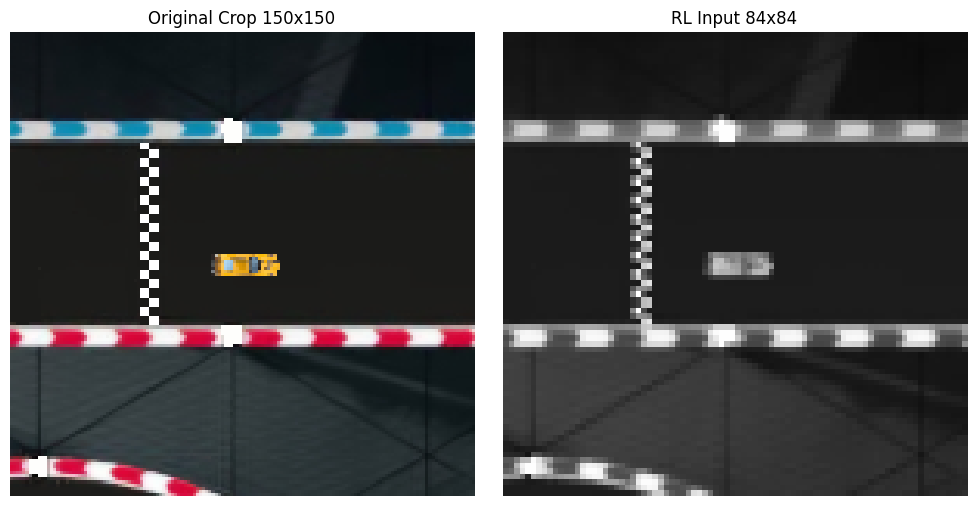

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Deine eigenen Klassen importieren
from src.envs.carrera_2d_env import Carrera2DEnv
from src.utils.virtual_camera import VirtualCamera

# 1. Environment & Kamera initialisieren
env = Carrera2DEnv('data/strecke.png', 'data/carrera_car.png')
env.reset()
camera = VirtualCamera(crop_size=(150, 150), target_size=(84, 84))

# 2. Den Pygame-Screen einmal im Hintergrund zeichnen lassen
env.render()

if env.screen is not None:
    # 3. Koordinaten abgreifen
    x_m, y_m = env.state[0], env.state[1]
    car_x_px = x_m * env.pixels_per_meter
    car_y_px = y_m * env.pixels_per_meter
    
    # 4. Bild mit unserer neuen Klasse abgreifen
    rl_obs, debug_crop = camera.get_car_centric_observation(env.screen, car_x_px, car_y_px)
    
    # --- 5. Visualisierung in der Notebook-Zelle ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Bild 1: Der rohe Ausschnitt (Für Matplotlib müssen wir BGR zu RGB tauschen)
    debug_crop_rgb = cv2.cvtColor(debug_crop, cv2.COLOR_BGR2RGB)
    axes[0].imshow(debug_crop_rgb)
    axes[0].set_title(f"Original Crop {camera.crop_width}x{camera.crop_height}")
    axes[0].axis('off')
    
    # Bild 2: Der RL-Input
    # rl_obs hat aktuell die Shape (1, 84, 84) wegen np.expand_dims. 
    # Matplotlib will für Graustufen aber nur (84, 84) haben, also ziehen wir den Index 0.
    rl_image = rl_obs[0] 
    
    # vmin und vmax sind wichtig, da unsere Werte zwischen 0.0 und 1.0 normalisiert sind!
    axes[1].imshow(rl_image, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"RL Input {camera.target_width}x{camera.target_height}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Environment wieder sauber schließen
env.close()